# Semantic Regression: Neural Data → Word Embeddings (New Data Format)

This notebook regresses neural activity onto word embeddings
(GloVe, FastText, Word2Vec, CLIP, ViT, DINOv2, SimCLR) using `BasicRegressor` with Kernel Ridge Regression.

**Data format:** `_df.pkl` files (primary neural data), `_labels.pkl` (trial metadata/categories), `_channels.pkl` (channel info).

### Pipeline
```
1. Load _df.pkl (neural data)  →  2. Bin & clean trials/channels
                                        ↓
3. Lemmatise target labels  →  4. Load embeddings (GloVe, FastText, Word2Vec, CLIP, ViT)
                                        ↓
5. KernelRidge regression (BasicRegressor)  →  6. Plot R² over time
```

## 1. Imports

In [1]:
import gc
import numpy as np
import os
import sys
import collections
import pickle as pk
import dill
import pandas as pd
from nltk.stem import WordNetLemmatizer
from sklearn.decomposition import PCA
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import Ridge
from torchtext.vocab import GloVe, FastText
import matplotlib.pyplot as plt

from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import Pipeline


# Ensure we are at the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

from utils.utils import remove_number, plot_accuracy_plotly
from models.model import BasicRegressor

%load_ext autoreload
%autoreload 2

print('All imports OK')

c:\Users\Owner\miniconda3\envs\Speech\lib\site-packages\torchtext\vocab\__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
c:\Users\Owner\miniconda3\envs\Speech\lib\site-packages\torchtext\utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
c:\Users\Owner\miniconda3\envs\Speech\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find ac

All imports OK


## 2. Configuration

In [2]:
data_folder = 'data'
patient = 'AZ'
task = 'picture_naming'

alpha = 0.05
bin_size = 100  # ms

# Paths
patient_folder = os.path.join(data_folder, patient)
df_path = os.path.join(patient_folder, f'{patient}_{task}_df.pkl')
labels_path = os.path.join(patient_folder, f'{patient}_{task}_labels.pkl')

# Channels: try task-specific first, then patient-level, then None if neither exists
task_channels_path = os.path.join(patient_folder, f'{patient}_{task}_channels.pkl')
patient_channels_path = os.path.join(patient_folder, f'{patient}_channels.pkl')
if os.path.exists(task_channels_path):
    channels_path = task_channels_path
elif os.path.exists(patient_channels_path):
    channels_path = patient_channels_path
else:
    channels_path = None

# Optional: xlsx mapping for semantic categories (fallback if _labels lacks 'class')
task_to_xlsx = {
    'picture_naming': os.path.join('data_archive', 'wordset picture naming expanded.xlsx'),
}

print(f'Patient: {patient}')
print(f'Task: {task}')
print(f'df_path: {df_path} (exists: {os.path.exists(df_path)})')
print(f'labels_path: {labels_path} (exists: {os.path.exists(labels_path)})')
print(f'channels_path: {channels_path} (exists: {os.path.exists(channels_path) if channels_path else "N/A - no channels file"})')


Patient: AZ
Task: picture_naming
df_path: data\AZ\AZ_picture_naming_df.pkl (exists: True)
labels_path: data\AZ\AZ_picture_naming_labels.pkl (exists: True)
channels_path: data\AZ\AZ_picture_naming_channels.pkl (exists: True)


## 3. Load Data

In [3]:
def load_pkl(path):
    """Load a dill-serialised pkl file."""
    with open(path, 'rb') as f:
        return dill.load(f)

# Load main data
trial_df = load_pkl(df_path)
if isinstance(trial_df, dict):
    trial_df = pd.DataFrame(trial_df)

# Load labels
labels_df = load_pkl(labels_path)
if isinstance(labels_df, dict):
    labels_df = pd.DataFrame(labels_df)

# Load channels (optional)
if channels_path is not None:
    channels_df = load_pkl(channels_path)
    if isinstance(channels_df, dict):
        channels_df = pd.DataFrame(channels_df)
else:
    channels_df = None

print(f'trial_df: {trial_df.shape}  columns: {list(trial_df.columns)}')
print(f'labels_df: {labels_df.shape}  columns: {list(labels_df.columns)}')
if channels_df is not None:
    print(f'channels_df: {channels_df.shape}  columns: {list(channels_df.columns)}')
else:
    print('channels_df: None (no channels file found)')


trial_df: (753, 13)  columns: ['session', 'hg_data', 'trial_onset', 'go_cue_onset', 'trial_offset', 'voice_onset', 'voice_offset', 'target_word', 'answered_word', 'bad_channels', 'bad_trials', 'fs', 'channel_names']
labels_df: (746, 10)  columns: ['target_word', 'answered_word', 'target_lexeme', 'answered_lexeme', 'class', 'class_idx', 'answered_lexeme_idx', 'homophone_target', 'homophone_answer', 'correct_response']
channels_df: (99, 6)  columns: ['channel_name', 'rois', 'primary_roi', 'LE', 'SA', 'clean']


In [4]:
# Inspect data
print('=== trial_df ===')
print(f'  hg_data shape (first trial): {trial_df["hg_data"].iloc[0].shape}')
print(f'  fs: {trial_df["fs"].iloc[0]}')
print(f'  sessions: {sorted(trial_df["session"].unique())}')
print(f'  target_word examples: {list(trial_df["target_word"].iloc[:5])}')
if 'bad_trials' in trial_df.columns:
    print(f'  bad_trials distribution: {trial_df["bad_trials"].value_counts().to_dict()}')
print()
print('=== labels_df ===')
print(f'  columns: {list(labels_df.columns)}')
if 'class' in labels_df.columns:
    print(f'  semantic classes: {sorted(labels_df["class"].unique())}')
print()
print('=== channels_df ===')
if channels_df is not None:
    print(f'  n_channels: {len(channels_df)}')
    if 'clean' in channels_df.columns:
        print(f'  clean channels: {channels_df["clean"].sum()} / {len(channels_df)}')
else:
    print('  no channels file found; channels will be inferred from data')


=== trial_df ===
  hg_data shape (first trial): (99, 10881)
  fs: 2000.0
  sessions: [0, 1, 2, 3]
  target_word examples: ['milk3', 'toe3', 'hand3', 'car1', 'flower2']
  bad_trials distribution: {True: 753}

=== labels_df ===
  columns: ['target_word', 'answered_word', 'target_lexeme', 'answered_lexeme', 'class', 'class_idx', 'answered_lexeme_idx', 'homophone_target', 'homophone_answer', 'correct_response']
  semantic classes: ['animal', 'body part', 'food/fruit', 'nature', 'object/tool', 'vehicle']

=== channels_df ===
  n_channels: 99
  clean channels: 97 / 99


## 4. Process Neural Data: Bin & Clean

In [5]:
# Extract fields from trial_df
fs = int(trial_df['fs'].iloc[0])
n_samples_per_bin = fs * bin_size // 1000

# Neural data: list of (n_channels, n_timepoints) arrays
data_list = list(trial_df['hg_data'].values)

# Timing (in seconds, relative to recording start per trial)
trial_onset = trial_df['trial_onset'].values.astype(float)
go_cue_onset = trial_df['go_cue_onset'].values.astype(float)
trial_offset = trial_df['trial_offset'].values.astype(float)
voice_onset = trial_df['voice_onset'].values.astype(float)
voice_offset = trial_df['voice_offset'].values.astype(float)

# Target labels from _df
target_labels = trial_df['target_word'].values.astype(str)
answer_labels = trial_df['answered_word'].values.astype(str)

# Bad trials (boolean: True = keep)
if 'bad_trials' in trial_df.columns:
    bad_trials = trial_df['bad_trials'].values.astype(bool)
else:
    bad_trials = np.ones(len(trial_df), dtype=bool)

print(f'fs: {fs} Hz')
print(f'n_samples_per_bin: {n_samples_per_bin}')
print(f'n_trials: {len(data_list)}')
print(f'hg_data shape (trial 0): {data_list[0].shape}  (n_channels, n_timepoints)')

fs: 2000 Hz
n_samples_per_bin: 200
n_trials: 753
hg_data shape (trial 0): (99, 10881)  (n_channels, n_timepoints)


In [6]:
# Determine bad channels
if channels_df is not None:
    channel_names_all = channels_df['channel_name'].values.astype(str)
    if 'clean' in channels_df.columns:
        clean_mask = channels_df['clean'].values.astype(bool)
        bad_channels = np.where(~clean_mask)[0]
    else:
        bad_channels = np.array([], dtype=int)
else:
    # No channels file: infer channel count from first trial, treat all as good
    n_channels_from_data = data_list[0].shape[0]
    channel_names_all = np.array([str(i) for i in range(n_channels_from_data)])
    bad_channels = np.array([], dtype=int)

# Also check per-trial bad_channels annotation in _df
if 'bad_channels' in trial_df.columns:
    for bc in trial_df['bad_channels'].values:
        if bc is not None and len(bc) > 0:
            # bad_channels entries may be channel names or indices
            for ch in np.asarray(bc).ravel():
                if isinstance(ch, (int, float, np.integer, np.floating)) and not np.isnan(ch):
                    bad_channels = np.union1d(bad_channels, [int(ch)])

remaining_channel_indices = np.delete(np.arange(len(channel_names_all)), bad_channels)
channel_names = channel_names_all[remaining_channel_indices]

print(f'Total channels: {len(channel_names_all)}')
print(f'Bad channels ({len(bad_channels)}): {bad_channels.tolist()}')
print(f'Remaining channels: {len(channel_names)}')
print(f'Good trials: {bad_trials.sum()} / {len(bad_trials)}')


Total channels: 99
Bad channels (2): [21, 50]
Remaining channels: 97
Good trials: 753 / 753


In [7]:
# Patient-specific channel selection
if patient == 'LH':
    lh_excluded_filtered = np.array([
        index for index, cn in enumerate(channel_names)
        if str(cn).startswith(('V', 'O'))
    ], dtype=int)
    if len(lh_excluded_filtered) > 0:
        lh_excluded_channels = remaining_channel_indices[lh_excluded_filtered]
        bad_channels = np.union1d(bad_channels, lh_excluded_channels).astype(int)
        channel_names = np.delete(channel_names, lh_excluded_filtered, axis=0)
        remaining_channel_indices = np.delete(np.arange(len(channel_names_all)), bad_channels)
        print(f'Removing LH shanks V/O: {channel_names_all[lh_excluded_channels].tolist()}')

print(f'Final channel count: {len(channel_names)}')

Final channel count: 97


In [8]:
# Bin the neural data
# hg_data is (n_channels, n_timepoints) per trial; stack after truncating to shortest trial
shortest_trial = min(d.shape[1] for d in data_list)
data = np.array([d[:, :shortest_trial] for d in data_list])  # (n_trials, n_channels, n_timepoints)
min_length = data.shape[2] // n_samples_per_bin * n_samples_per_bin
data = data[:, :, :min_length]
data_binned = data.reshape(data.shape[0], data.shape[1], -1, n_samples_per_bin).mean(axis=3)

del data
gc.collect()

adjusted_fs = int(1000 / bin_size)
print(f'data_binned shape: {data_binned.shape}  (n_trials, n_channels, n_bins)')

data_binned shape: (753, 99, 50)  (n_trials, n_channels, n_bins)


In [9]:
# Remove bad channels and bad trials
clean_data_binned = np.delete(data_binned, bad_channels, axis=1)
clean_data_binned = clean_data_binned[bad_trials]
clean_voice_onset = voice_onset[bad_trials]
clean_voice_offset = voice_offset[bad_trials]
clean_target_labels = target_labels[bad_trials]
clean_answer_labels = answer_labels[bad_trials]
clean_channel_names = np.array(channel_names)

n_clean_channels = clean_data_binned.shape[1]
n_clean_trials = clean_data_binned.shape[0]

print(f'clean_data_binned shape: {clean_data_binned.shape}')
print(f'n_clean_trials={n_clean_trials}, n_clean_channels={n_clean_channels}')

clean_data_binned shape: (753, 97, 50)
n_clean_trials=753, n_clean_channels=97


In [10]:
# Optional: select shanks of interest (sEEG patients)
# Uncomment and modify the lines below as needed

# shank_of_interest = ['T', 'J', 'S']
# shank_mask = np.array([str(cn)[0] in shank_of_interest for cn in clean_channel_names])
# clean_data_binned = clean_data_binned[:, shank_mask, :]
# clean_channel_names = clean_channel_names[shank_mask]
# n_clean_channels = clean_data_binned.shape[1]
# print(f'After shank selection: {clean_data_binned.shape}')

## 5. Assign Semantic Categories

In [11]:
# Assign semantic categories from _labels 'class' column or xlsx fallback
if 'class' in labels_df.columns:
    # Match labels_df to clean trials via target_word
    labels_word_to_class = dict(zip(
        labels_df['target_word'].astype(str),
        labels_df['class'].astype(str)
    ))
    word_category = np.array([
        labels_word_to_class.get(w, 'unknown') for w in clean_target_labels
    ])
    # Fallback: for 'unknown' entries, try matching via lexeme (number-stripped)
    # e.g. if "hill5" isn't in labels_df but "hill3" is, use its category
    n_unknown_before = np.sum(word_category == 'unknown')
    if n_unknown_before > 0:
        # Build base-word -> category from known mappings
        _base_to_cat = {}
        for raw_label, cat in labels_word_to_class.items():
            base = remove_number(str(raw_label)).lower()
            if base not in _base_to_cat:
                _base_to_cat[base] = cat
        # Fill unknowns
        for i, (w, cat) in enumerate(zip(clean_target_labels, word_category)):
            if cat == 'unknown':
                base = remove_number(str(w)).lower()
                word_category[i] = _base_to_cat.get(base, 'unknown')
        n_unknown_after = np.sum(word_category == 'unknown')
        print(f'Resolved {n_unknown_before - n_unknown_after}/{n_unknown_before} unknowns via base-word fallback')
    print(f'Categories from _labels.pkl')
elif task in task_to_xlsx and os.path.exists(task_to_xlsx[task]):
    xlsx_path = task_to_xlsx[task]
    df_xlsx = pd.read_excel(xlsx_path)
    word_column = df_xlsx.columns[0]
    df_xlsx.set_index(word_column, inplace=True)
    df_filled = df_xlsx.fillna(0).apply(pd.to_numeric)
    category_series = df_filled.idxmax(axis=1).reset_index()
    category_series.columns = [word_column, 'Category']
    word_to_category_dict = dict(zip(category_series[word_column], category_series['Category']))
    
    target_lexeme_temp = np.array([remove_number(t).lower() for t in clean_target_labels])
    word_category = np.array([
        word_to_category_dict.get(w, 'unknown') for w in target_lexeme_temp
    ])
    # Merge similar categories
    word_category = np.array([
        'food and fruit' if w in ('fruit', 'food (exclude fruit)') else w
        for w in word_category
    ])
    print(f'Categories from xlsx: {xlsx_path}')
else:
    word_category = np.array(['unknown'] * n_clean_trials)
    print('Warning: no category source available')

clean_word_category = word_category
print(collections.Counter(clean_word_category))

Categories from _labels.pkl
Counter({'object/tool': 154, 'food/fruit': 133, 'animal': 132, 'nature': 113, 'body part': 112, 'vehicle': 109})


## 6. Lemmatise Target Words

In [12]:
lemmatizer = WordNetLemmatizer()

# target_lexeme: number-stripped labels (preserves meaning numbers for homonyms)
# e.g. "mouse11" -> "mouse1", "bank5" -> "bank"
if 'Flashing' in task or 'auditory' in task or 'picture' in task:
    target_lexeme = np.array([remove_number(t) for t in clean_target_labels])
else:
    target_lexeme = clean_target_labels.copy()

target_lexeme = np.array([str(w).lower() for w in target_lexeme])

# target_lemma: lemmatised form for static text embeddings (strips ALL numbers)
# Used ONLY for embedding lookup (GloVe, Word2Vec, etc.)
target_lemma = np.array([
    lemmatizer.lemmatize(''.join([c for c in a if c.isalpha()]), pos='n')
    for a in target_lexeme
])

# target_concept: disambiguated concept labels for retrieval accuracy
# Ambiguous bases become base(category) on a per-sample basis; others stay base
_base_of_lexeme = np.array([
    ''.join([c for c in w if c.isalpha()]) for w in target_lexeme
])  # e.g. "mouse1" -> "mouse", "bank" -> "bank"

# Detect ambiguous bases: multiple lexeme variants or multiple categories
_unique_lexemes = np.unique(target_lexeme)
_base_to_variants = {}
for lex in _unique_lexemes:
    base = ''.join([c for c in lex if c.isalpha()])
    _base_to_variants.setdefault(base, set()).add(lex)

_base_to_categories = {}
for base, cat in zip(_base_of_lexeme, clean_word_category):
    _base_to_categories.setdefault(base, set()).add(cat)

_ambiguous_bases = {
    base for base in _base_to_variants
    if len(_base_to_variants[base]) > 1 or len(_base_to_categories.get(base, set())) > 1
}

# Build target_concept directly from each sample's own category
target_concept = np.array([
    f"{base}({cat})" if base in _ambiguous_bases else base
    for base, cat in zip(_base_of_lexeme, clean_word_category)
])

# Print diagnostics
if _ambiguous_bases:
    print(f'Detected {len(_ambiguous_bases)} homonym/ambiguous base(s):')
    for base in sorted(_ambiguous_bases):
        variants = sorted(_base_to_variants[base])
        cats = sorted(_base_to_categories.get(base, []))
        concepts = sorted(np.unique(target_concept[_base_of_lexeme == base]))
        print(f'  {base}: variants={variants}, categories={cats}, concepts={concepts}')
else:
    print('No homonyms detected')

print(f'\nUnique target labels: {len(np.unique(clean_target_labels))}')
print(f'Unique number-stripped lexemes: {len(np.unique(target_lexeme))}')
print(f'Unique lemmatised words (embedding lookup): {len(np.unique(target_lemma))}')
print(f'Unique concepts (retrieval labels): {len(np.unique(target_concept))}')
print(f'Label examples: {clean_target_labels[:10]}')
print(f'Lexeme examples: {target_lexeme[:10]}')
print(f'Concept examples: {target_concept[:10]}')

Detected 4 homonym/ambiguous base(s):
  bat: variants=['bat1', 'bat2'], categories=['animal', 'object/tool'], concepts=['bat(animal)', 'bat(object/tool)']
  mouse: variants=['mouse1', 'mouse2'], categories=['animal', 'object/tool'], concepts=['mouse(animal)', 'mouse(object/tool)']
  nail: variants=['nail1', 'nail2'], categories=['body part', 'object/tool'], concepts=['nail(body part)', 'nail(object/tool)']
  nut: variants=['nut1', 'nut2'], categories=['food/fruit', 'object/tool'], concepts=['nut(food/fruit)', 'nut(object/tool)']

Unique target labels: 204
Unique number-stripped lexemes: 68
Unique lemmatised words (embedding lookup): 64
Unique concepts (retrieval labels): 68
Label examples: ['milk3' 'toe3' 'hand3' 'car1' 'flower2' 'nut21' 'wrench3' 'cow3'
 'hurricane3' 'mouth1']
Lexeme examples: ['milk' 'toe' 'hand' 'car' 'flower' 'nut2' 'wrench' 'cow' 'hurricane'
 'mouth']
Concept examples: ['milk' 'toe' 'hand' 'car' 'flower' 'nut(object/tool)' 'wrench' 'cow'
 'hurricane' 'mouth']


## 7. Load Word Embeddings

We load seven families of embeddings as regression targets:
- **GloVe** (840B, 300-D)
- **FastText** (Simple Wikipedia, 300-D)
- **Word2Vec** (Google News, 300-D)
- **CLIP ViT-B/32** (projected image 512-D, text 512-D)
- **ViT-B/32 ImageNet** (pooled 768-D)
- **DINOv2-B** (pooled 768-D)
- **SimCLR** (pooled 2048-D)

See `embedding_comparison.ipynb` for details on how these embeddings are generated and compared.

In [13]:
# -- Static text embeddings ---------------------------------------------------
embed_ft = FastText(language='simple')
target_word_embed_FastText = [embed_ft[w].numpy() for w in target_lemma]
del embed_ft

embed_glove = GloVe(dim=300, name='840B')
target_word_embed_GloVe = [embed_glove[w].numpy() for w in target_lemma]
del embed_glove

import gensim.downloader as gensim_api
w2v_model = gensim_api.load('word2vec-google-news-300')
target_word_embed_Word2Vec = np.array([
    w2v_model[w] if w in w2v_model else np.zeros(300)
    for w in target_lemma
])
del w2v_model
gc.collect()

print(f'GloVe    : {np.array(target_word_embed_GloVe).shape}')
print(f'FastText : {np.array(target_word_embed_FastText).shape}')
print(f'Word2Vec : {target_word_embed_Word2Vec.shape}')

GloVe    : (753, 300)
FastText : (753, 300)
Word2Vec : (753, 300)


In [14]:
# -- Multimodal embeddings (pre-computed) ------------------------------------
image_folder = os.path.join(data_folder, 'pictureNaming extended all')
embeddings_folder = os.path.join('embeddings', os.path.basename(image_folder))

def _normalize_tokens(tokens):
    return np.array([str(t).strip().lower() for t in tokens])

def _map_to_target(results_dict, key, target_labels, words_arr):
    """Return [N_words, D] array aligned to target_labels."""
    words_norm = _normalize_tokens(words_arr)
    labels_norm = _normalize_tokens(target_labels)
    lookup = {w: i for i, w in enumerate(words_norm)}

    out = []
    missing = []
    for t_raw, t_norm in zip(target_labels, labels_norm):
        if t_norm not in lookup:
            missing.append(t_raw)
            continue
        out.append(np.asarray(results_dict[key][lookup[t_norm]]).squeeze())

    if missing:
        print(f"{key}: missing {len(missing)} labels, e.g. {missing[:10]}")

    return np.array(out)

def _layer_keys(results_dict, prefix):
    """Return sorted layer keys like text_layer_00..text_layer_12."""
    keys = [k for k in results_dict.keys() if k.startswith(prefix)]
    return sorted(keys, key=lambda x: int(x.split('_')[-1]))

def _first_existing_key(results_dict, candidate_keys):
    for k in candidate_keys:
        if k in results_dict:
            return k
    raise KeyError(f"None of {candidate_keys} found in results keys")

# -- CLIP layer-wise text -----------------------------------------------------
clip_layerwise_pkl = os.path.join(embeddings_folder, 'clip_layerwise_embeddings.pk')
with open(clip_layerwise_pkl, 'rb') as f:
    clip_layerwise_results = pk.load(f)
clip_layerwise_words = np.array(clip_layerwise_results['words'])
clip_text_layer_keys = _layer_keys(clip_layerwise_results, 'text_layer_')
target_word_embed_CLIP_text_layers = {
    k: _map_to_target(clip_layerwise_results, k, clean_target_labels, clip_layerwise_words)
    for k in clip_text_layer_keys
}
del clip_layerwise_results, clip_layerwise_words
print(f'CLIP text layers: {len(clip_text_layer_keys)} keys')
print(f'Example {clip_text_layer_keys[0]} shape: {target_word_embed_CLIP_text_layers[clip_text_layer_keys[0]].shape}')

# -- ViT ImageNet (pooled + layer-wise) --------------------------------------
vit_pkl = os.path.join(embeddings_folder, 'vit_imagenet_layerwise_embeddings.pk')
with open(vit_pkl, 'rb') as f:
    vit_results = pk.load(f)
vit_words = np.array(vit_results['words'])
target_word_embed_ViT = _map_to_target(vit_results, 'vit_pooled', clean_target_labels, vit_words)
vit_layer_keys = _layer_keys(vit_results, 'vit_layer_')
target_word_embed_ViT_layers = {
    k: _map_to_target(vit_results, k, clean_target_labels, vit_words)
    for k in vit_layer_keys
}
del vit_results, vit_words
print(f'ViT pooled : {target_word_embed_ViT.shape}')
print(f'ViT layers: {len(vit_layer_keys)} keys')

# -- DINOv2 (pooled + layer-wise) --------------------------------------------
dinov2_pkl = os.path.join(embeddings_folder, 'dinov2_layerwise_embeddings.pk')
with open(dinov2_pkl, 'rb') as f:
    dinov2_results = pk.load(f)
dinov2_words = np.array(dinov2_results['words'])
target_word_embed_DINOv2 = _map_to_target(dinov2_results, 'dinov2_pooled', clean_target_labels, dinov2_words)
dinov2_layer_keys = _layer_keys(dinov2_results, 'dinov2_layer_')
target_word_embed_DINOv2_layers = {
    k: _map_to_target(dinov2_results, k, clean_target_labels, dinov2_words)
    for k in dinov2_layer_keys
}
del dinov2_results, dinov2_words
print(f'DINOv2 pooled : {target_word_embed_DINOv2.shape}')
print(f'DINOv2 layers: {len(dinov2_layer_keys)} keys')


# -- SimCLR (pooled + layer-wise) --------------------------------------------
simclr_pkl = os.path.join(embeddings_folder, 'simclr_layerwise_embeddings.pk')
with open(simclr_pkl, 'rb') as f:
    simclr_results = pk.load(f)
simclr_words = np.array(simclr_results['words'])
target_word_embed_SimCLR = _map_to_target(simclr_results, 'simclr_pooled', clean_target_labels, simclr_words)
simclr_layer_keys = _layer_keys(simclr_results, 'simclr_layer_')
target_word_embed_SimCLR_layers = {
    k: _map_to_target(simclr_results, k, clean_target_labels, simclr_words)
    for k in simclr_layer_keys
}
del simclr_results, simclr_words
gc.collect()
print(f'SimCLR pooled : {target_word_embed_SimCLR.shape}')
print(f'SimCLR layers: {len(simclr_layer_keys)} keys')

CLIP text layers: 13 keys
Example text_layer_00 shape: (753, 512)
ViT pooled : (753, 768)
ViT layers: 13 keys
DINOv2 pooled : (753, 768)
DINOv2 layers: 13 keys
SimCLR pooled : (753, 2048)
SimCLR layers: 5 keys


In [15]:
# -- ConceptNet Numberbatch embeddings -------------------------------------------
import gzip
from urllib.request import urlretrieve

conceptnet_url = 'https://conceptnet.s3.amazonaws.com/downloads/2019/numberbatch/numberbatch-en-19.08.txt.gz'
conceptnet_cache_path = os.path.join(data_folder, 'conceptnet-en-19.08.txt.gz')

# Download if not already cached
if not os.path.exists(conceptnet_cache_path):
    print(f'Downloading ConceptNet Numberbatch from {conceptnet_url}...')
    urlretrieve(conceptnet_url, conceptnet_cache_path)
    print(f'Downloaded to {conceptnet_cache_path}')
else:
    print(f'Using cached ConceptNet file: {conceptnet_cache_path}')

# Load and parse ConceptNet Numberbatch (English-only version uses plain words, not URIs)
conceptnet_embeddings = {}
with gzip.open(conceptnet_cache_path, 'rt', encoding='utf-8') as f:
    header = f.readline().strip().split()
    n_words, embedding_dim = int(header[0]), int(header[1])
    print(f'Expected: {n_words} words, {embedding_dim} dimensions')
    
    for i, line in enumerate(f):
        if i % 100000 == 0:
            print(f'  Loaded {i}/{n_words} entries...')
        parts = line.strip().split(' ')
        word = parts[0]
        # Strip /c/en/ prefix if present (multilingual file), otherwise use as-is
        if word.startswith('/c/en/'):
            word = word[6:]
        embedding = np.array(parts[1:], dtype=np.float32)
        if len(embedding) == embedding_dim:
            conceptnet_embeddings[word] = embedding

print(f'Loaded {len(conceptnet_embeddings)} ConceptNet embeddings')

# Map to target lemmas
target_word_embed_ConceptNet = np.array([
    conceptnet_embeddings.get(w, np.zeros(300, dtype=np.float32))
    for w in target_lemma
], dtype=np.float32)

n_found = sum(1 for w in target_lemma if w in conceptnet_embeddings)
n_missing = len(target_lemma) - n_found
if n_missing > 0:
    missing_unique = sorted(set(w for w in target_lemma if w not in conceptnet_embeddings))
    print(f'Missing {n_missing} embeddings ({len(missing_unique)} unique words): {missing_unique[:20]}')

print(f'ConceptNet: {target_word_embed_ConceptNet.shape}')
print(f'Found embeddings for {n_found}/{len(target_lemma)} target words')


Using cached ConceptNet file: data\conceptnet-en-19.08.txt.gz
Expected: 516782 words, 300 dimensions
  Loaded 0/516782 entries...
  Loaded 100000/516782 entries...
  Loaded 200000/516782 entries...
  Loaded 300000/516782 entries...
  Loaded 400000/516782 entries...
  Loaded 500000/516782 entries...
Loaded 516782 ConceptNet embeddings
ConceptNet: (753, 300)
Found embeddings for 753/753 target words


## 8. Regression: Neural Activity → Embeddings

For each embedding type we fit a `BasicRegressor` (KernelRidge with RBF kernel)
that maps `clean_data_binned` → embedding, sliding across time bins.

In [16]:
# ── Regression parameters ────────────────────────────────────────
n_bins_history = 10
n_epochs = 50
y_pca_components = 10
krr_alpha = 1.5

In [ ]:
# ── GloVe regression ─────────────────────────────────────────────
y_reducer = PCA(y_pca_components)
nystroem = Nystroem(kernel='rbf')
regressor = Pipeline([
    ('nystroem', nystroem),
    ('ridge', Ridge(alpha=krr_alpha))
])

br_GloVe = BasicRegressor(regressor, y_reducer=y_reducer)
br_GloVe.load_data(clean_data_binned.swapaxes(1, 2), target_word_embed_GloVe, n_bins_history=n_bins_history, labels=target_concept, category_labels=clean_word_category)
br_GloVe.fit(n_epochs=n_epochs, parallel=10, compute_retrieval=True, save_retrieval_pairs=True)
print('GloVe regression done')

In [ ]:
# ── Word2Vec regression ──────────────────────────────────────────────────
y_reducer = PCA(y_pca_components)
nystroem = Nystroem(kernel='rbf')
regressor = Pipeline([
    ('nystroem', nystroem),
    ('ridge', Ridge(alpha=krr_alpha))
])

br_Word2Vec = BasicRegressor(regressor, y_reducer=y_reducer)
br_Word2Vec.load_data(clean_data_binned.swapaxes(1, 2), target_word_embed_Word2Vec, n_bins_history=n_bins_history, labels=target_concept, category_labels=clean_word_category)
br_Word2Vec.fit(n_epochs=n_epochs, parallel=10, compute_retrieval=True, save_retrieval_pairs=True)
print('Word2Vec regression done')

Word2Vec regression done


In [ ]:
# ── ConceptNet regression ───────────────────────────────────────────────────
y_reducer = PCA(y_pca_components)
nystroem = Nystroem(kernel='rbf')
regressor = Pipeline([
    ('nystroem', nystroem),
    ('ridge', Ridge(alpha=krr_alpha))
])

br_ConceptNet = BasicRegressor(regressor, y_reducer=y_reducer)
br_ConceptNet.load_data(clean_data_binned.swapaxes(1, 2), target_word_embed_ConceptNet, n_bins_history=n_bins_history, labels=target_concept, category_labels=clean_word_category)
br_ConceptNet.fit(n_epochs=n_epochs, parallel=10, compute_retrieval=True, save_retrieval_pairs=True)
print('ConceptNet regression done')


ConceptNet regression done


In [ ]:
# ── FastText regression ──────────────────────────────────────────
y_reducer = PCA(y_pca_components)
regressor = KernelRidge(alpha=krr_alpha, kernel='rbf')

br_FastText = BasicRegressor(regressor, y_reducer=y_reducer)
br_FastText.load_data(
    clean_data_binned.swapaxes(1, 2),
    target_word_embed_FastText,
    n_bins_history=n_bins_history,
    labels=target_concept,
    category_labels=clean_word_category,
)
br_FastText.fit(
    n_epochs=n_epochs,
    parallel=10,
    compute_retrieval=True,
    save_retrieval_pairs=True,
)
print('FastText regression done')

FastText regression done


In [ ]:
# # ── CLIP image regression ────────────────────────────────────────
# y_reducer = PCA(y_pca_components)
# regressor = KernelRidge(alpha=krr_alpha, kernel='rbf')

# br_CLIP_images = BasicRegressor(regressor, y_reducer=y_reducer)
# br_CLIP_images.load_data(clean_data_binned.swapaxes(1, 2), target_word_embed_CLIP_images, n_bins_history=n_bins_history)
# br_CLIP_images.fit(n_epochs=n_epochs)
# print('CLIP image regression done')

In [ ]:
# # ── CLIP text regression ─────────────────────────────────────────
# y_reducer = PCA(y_pca_components)
# regressor = KernelRidge(alpha=krr_alpha, kernel='rbf')

# br_CLIP_words = BasicRegressor(regressor, y_reducer=y_reducer)
# br_CLIP_words.load_data(clean_data_binned.swapaxes(1, 2), target_word_embed_CLIP_words, n_bins_history=n_bins_history)
# br_CLIP_words.fit(n_epochs=n_epochs)
# print('CLIP text regression done')

In [ ]:
# # ── ViT regression ───────────────────────────────────────────────
# y_reducer = PCA(y_pca_components)
# regressor = KernelRidge(alpha=krr_alpha, kernel='rbf')

# br_ViT = BasicRegressor(regressor, y_reducer=y_reducer)
# br_ViT.load_data(clean_data_binned.swapaxes(1, 2), target_word_embed_ViT, n_bins_history=n_bins_history)
# br_ViT.fit(n_epochs=n_epochs)
# print('ViT regression done')

In [ ]:
# ── DINOv2 regression ────────────────────────────────────────────
y_reducer = PCA(y_pca_components)
nystroem = Nystroem(kernel='rbf')
regressor = Pipeline([
    ('nystroem', nystroem),
    ('ridge', Ridge(alpha=krr_alpha))
])

br_DINOv2 = BasicRegressor(regressor, y_reducer=y_reducer)
br_DINOv2.load_data(clean_data_binned.swapaxes(1, 2), target_word_embed_DINOv2, n_bins_history=n_bins_history, labels=target_concept, category_labels=clean_word_category)
br_DINOv2.fit(n_epochs=n_epochs, parallel=10, compute_retrieval=True, save_retrieval_pairs=True)
print('DINOv2 regression done')

DINOv2 regression done


In [ ]:
# ── MAE regression ────────────────────────────────────────────
# y_reducer = PCA(y_pca_components)
# nystroem = Nystroem(kernel='rbf')
# regressor = Pipeline([
#     ('nystroem', nystroem),
#     ('ridge', Ridge(alpha=krr_alpha))
# ])

# br_MAE = BasicRegressor(regressor, y_reducer=y_reducer)
# br_MAE.load_data(clean_data_binned.swapaxes(1, 2), target_word_embed_MAE, n_bins_history=n_bins_history)
# br_MAE.fit(n_epochs=n_epochs, parallel=10)
# print('MAE regression done')

In [ ]:
# ── SimCLR regression ────────────────────────────────────────────
y_reducer = PCA(y_pca_components)
nystroem = Nystroem(kernel='rbf')
regressor = Pipeline([
    ('nystroem', nystroem),
    ('ridge', Ridge(alpha=krr_alpha))
])

br_SimCLR = BasicRegressor(regressor, y_reducer=y_reducer)
br_SimCLR.load_data(clean_data_binned.swapaxes(1, 2), target_word_embed_SimCLR, n_bins_history=n_bins_history, labels=target_concept, category_labels=clean_word_category)
br_SimCLR.fit(n_epochs=n_epochs, parallel=10, compute_retrieval=True, save_retrieval_pairs=True)
print('SimCLR regression done')

SimCLR regression done


## 9. Plot Regression Results (R² over Time)

In [ ]:
fig, ax = plot_accuracy_plotly(
    br_GloVe.all_test_score.mean(0),
    br_FastText.all_test_score.mean(0),
    br_Word2Vec.all_test_score.mean(0),
    br_ConceptNet.all_test_score.mean(0),
    br_DINOv2.all_test_score.mean(0),
    br_SimCLR.all_test_score.mean(0),
    br_GloVe.all_chance.mean(0),
    lines=[
        0 - np.nanmean(trial_onset),
        np.nanmean(go_cue_onset) - np.nanmean(trial_onset),
        np.nanmean(clean_voice_onset) - np.nanmean(trial_onset),
        np.nanmean(clean_voice_offset) - np.nanmean(trial_onset),
    ],
    data_std=[
        0,
        0,
        0,
        0,
        0,
        0,
        br_GloVe.all_chance.std(0),
    ],
    line_labels=['trial onset', 'go cue', 'voice on', 'voice off'],
    data_labels=['GloVe', 'FastText', 'Word2Vec', 'ConceptNet', 'DINOv2', 'SimCLR', 'chance'],
    back=np.nanmean(trial_onset),
    forward=clean_data_binned.shape[2] / adjusted_fs - np.nanmean(trial_onset),
    ylabel='1-SSE/SST (R²)',
    tick_interval=1,
    title='Aligned to Trial Onset: Regression to Word Embeddings',
)

fig.show()


In [ ]:
# Word retrieval: balanced accuracy over time
fig_wbal, _ = plot_accuracy_plotly(
    np.mean(br_GloVe.all_retrieval_word_balanced_acc, axis=0),
    np.mean(br_FastText.all_retrieval_word_balanced_acc, axis=0),
    np.mean(br_Word2Vec.all_retrieval_word_balanced_acc, axis=0),
    np.mean(br_ConceptNet.all_retrieval_word_balanced_acc, axis=0),
    np.mean(br_DINOv2.all_retrieval_word_balanced_acc, axis=0),
    np.mean(br_SimCLR.all_retrieval_word_balanced_acc, axis=0),
    np.mean(br_GloVe.all_retrieval_chance_word_balanced_acc, axis=0),
    lines=[
        0 - np.nanmean(trial_onset),
        np.nanmean(go_cue_onset) - np.nanmean(trial_onset),
        np.nanmean(clean_voice_onset) - np.nanmean(trial_onset),
        np.nanmean(clean_voice_offset) - np.nanmean(trial_onset),
    ],
    data_std=[
        0,
        0,
        0,
        0,
        0,
        0,
        np.std(br_GloVe.all_retrieval_chance_word_balanced_acc, axis=0),
    ],
    line_labels=['trial onset', 'go cue', 'voice on', 'voice off'],
    data_labels=['GloVe', 'FastText', 'Word2Vec', 'ConceptNet', 'DINOv2', 'SimCLR', 'shuffled chance'],
    back=np.nanmean(trial_onset),
    forward=clean_data_binned.shape[2] / adjusted_fs - np.nanmean(trial_onset),
    ylabel='Balanced Accuracy',
    tick_interval=1,
    title='Aligned to Trial Onset: Word Retrieval Balanced Accuracy',
)
fig_wbal.show()

In [ ]:
# # Word retrieval: macro F1 over time
# fig_wf1, _ = plot_accuracy_plotly(
#     np.mean(br_GloVe.all_retrieval_word_f1, axis=0),
#     np.mean(br_FastText.all_retrieval_word_f1, axis=0),
#     np.mean(br_Word2Vec.all_retrieval_word_f1, axis=0),
#     np.mean(br_ConceptNet.all_retrieval_word_f1, axis=0),
#     np.mean(br_DINOv2.all_retrieval_word_f1, axis=0),
#     np.mean(br_SimCLR.all_retrieval_word_f1, axis=0),
#     np.mean(br_GloVe.all_retrieval_chance_word_f1, axis=0),
#     lines=[
#         0 - np.nanmean(trial_onset),
#         np.nanmean(go_cue_onset) - np.nanmean(trial_onset),
#         np.nanmean(clean_voice_onset) - np.nanmean(trial_onset),
#         np.nanmean(clean_voice_offset) - np.nanmean(trial_onset),
#     ],
#     data_std=[
#         0,
#         0,
#         0,
#         0,
#         0,
#         0,
#         np.std(br_GloVe.all_retrieval_chance_word_f1, axis=0),
#     ],
#     line_labels=['trial onset', 'go cue', 'voice on', 'voice off'],
#     data_labels=['GloVe', 'FastText', 'Word2Vec', 'ConceptNet', 'DINOv2', 'SimCLR', 'shuffled chance'],
#     back=np.nanmean(trial_onset),
#     forward=clean_data_binned.shape[2] / adjusted_fs - np.nanmean(trial_onset),
#     ylabel='Macro F1',
#     tick_interval=1,
#     title='Aligned to Trial Onset: Word Retrieval Macro F1',
# )
# fig_wf1.show()

In [ ]:
# Category retrieval: balanced accuracy over time
fig_cbal, _ = plot_accuracy_plotly(
    np.mean(br_GloVe.all_retrieval_category_balanced_acc, axis=0),
    np.mean(br_FastText.all_retrieval_category_balanced_acc, axis=0),
    np.mean(br_Word2Vec.all_retrieval_category_balanced_acc, axis=0),
    np.mean(br_ConceptNet.all_retrieval_category_balanced_acc, axis=0),
    np.mean(br_DINOv2.all_retrieval_category_balanced_acc, axis=0),
    np.mean(br_SimCLR.all_retrieval_category_balanced_acc, axis=0),
    np.mean(br_GloVe.all_retrieval_category_chance_balanced_acc, axis=0),
    lines=[
        0 - np.nanmean(trial_onset),
        np.nanmean(go_cue_onset) - np.nanmean(trial_onset),
        np.nanmean(clean_voice_onset) - np.nanmean(trial_onset),
        np.nanmean(clean_voice_offset) - np.nanmean(trial_onset),
    ],
    data_std=[
        0,
        0,
        0,
        0,
        0,
        0,
        np.std(br_GloVe.all_retrieval_category_chance_balanced_acc, axis=0),
    ],
    line_labels=['trial onset', 'go cue', 'voice on', 'voice off'],
    data_labels=['GloVe', 'FastText', 'Word2Vec', 'ConceptNet', 'DINOv2', 'SimCLR', 'shuffled chance'],
    back=np.nanmean(trial_onset),
    forward=clean_data_binned.shape[2] / adjusted_fs - np.nanmean(trial_onset),
    ylabel='Balanced Accuracy',
    tick_interval=1,
    title='Aligned to Trial Onset: Category Retrieval Balanced Accuracy',
)
fig_cbal.show()

In [ ]:
# # Category retrieval: macro F1 over time
# fig_cf1, _ = plot_accuracy_plotly(
#     np.mean(br_GloVe.all_retrieval_category_f1, axis=0),
#     np.mean(br_FastText.all_retrieval_category_f1, axis=0),
#     np.mean(br_Word2Vec.all_retrieval_category_f1, axis=0),
#     np.mean(br_ConceptNet.all_retrieval_category_f1, axis=0),
#     np.mean(br_DINOv2.all_retrieval_category_f1, axis=0),
#     np.mean(br_SimCLR.all_retrieval_category_f1, axis=0),
#     np.mean(br_GloVe.all_retrieval_category_chance_f1, axis=0),
#     lines=[
#         0 - np.nanmean(trial_onset),
#         np.nanmean(go_cue_onset) - np.nanmean(trial_onset),
#         np.nanmean(clean_voice_onset) - np.nanmean(trial_onset),
#         np.nanmean(clean_voice_offset) - np.nanmean(trial_onset),
#     ],
#     data_std=[
#         0,
#         0,
#         0,
#         0,
#         0,
#         0,
#         np.std(br_GloVe.all_retrieval_category_chance_f1, axis=0),
#     ],
#     line_labels=['trial onset', 'go cue', 'voice on', 'voice off'],
#     data_labels=['GloVe', 'FastText', 'Word2Vec', 'ConceptNet', 'DINOv2', 'SimCLR', 'shuffled chance'],
#     back=np.nanmean(trial_onset),
#     forward=clean_data_binned.shape[2] / adjusted_fs - np.nanmean(trial_onset),
#     ylabel='Macro F1',
#     tick_interval=1,
#     title='Aligned to Trial Onset: Category Retrieval Macro F1',
# )
# fig_cf1.show()

In [ ]:
import math
from sklearn.metrics import confusion_matrix

def _best_bin_from_top1(br, mode='word'):
    if mode == 'category' and hasattr(br, 'all_retrieval_category_top1') and br.all_retrieval_category_top1 is not None:
        top1 = np.asarray(br.all_retrieval_category_top1)
    else:
        top1 = np.asarray(br.all_retrieval_top1)
    if top1.ndim != 2:
        raise ValueError('Expected top1 to have shape [epochs, bins]')
    return int(np.nanargmax(np.nanmean(top1, axis=0)))

def _collect_pairs_at_bin(br, bin_index):
    true_idx = []
    pred_idx = []
    for epoch_pairs in br.all_retrieval_pairs:
        for rec in epoch_pairs:
            if int(rec['bin_index']) == int(bin_index):
                true_idx.append(np.asarray(rec['true_word_idx'], dtype=np.int64))
                pred_idx.append(np.asarray(rec['pred_word_idx'], dtype=np.int64))

    if not true_idx:
        raise ValueError(
            f'No retrieval pairs found for bin {bin_index}. Did you run fit with save_retrieval_pairs=True?'
        )

    return np.concatenate(true_idx), np.concatenate(pred_idx)

def _make_cm(br, bin_index=None, mode='word'):
    if bin_index is None:
        bin_index = _best_bin_from_top1(br, mode=mode)

    y_true_word, y_pred_word = _collect_pairs_at_bin(br, bin_index)

    if mode == 'word':
        int_labels = np.arange(len(br.index_to_word), dtype=np.int64)
        y_true = y_true_word
        y_pred = y_pred_word
        names = np.asarray(br.index_to_word)
    elif mode == 'category':
        if br.word_index_to_category_index is None or len(br.index_to_category) == 0:
            raise ValueError('Category mapping not available for this regressor')
        int_labels = np.arange(len(br.index_to_category), dtype=np.int64)
        y_true = br.word_index_to_category_index[y_true_word].astype(np.int64)
        y_pred = br.word_index_to_category_index[y_pred_word].astype(np.int64)
        names = np.asarray(br.index_to_category)
    else:
        raise ValueError("mode must be 'word' or 'category'")

    cm = confusion_matrix(y_true, y_pred, labels=int_labels)
    return cm, names, bin_index

def _normalize_col(cm):
    cm = cm.astype(float)
    col_sum = cm.sum(axis=0, keepdims=True)
    col_sum[col_sum == 0] = 1.0
    return cm / col_sum

def _rank_labels_by_f1(cm):
    # Per-class F1 from one-vs-rest counts computed from confusion matrix.
    tp = np.diag(cm).astype(float)
    fp = cm.sum(axis=0).astype(float) - tp
    fn = cm.sum(axis=1).astype(float) - tp
    denom = 2.0 * tp + fp + fn
    f1 = np.divide(tp * 2.0, denom, out=np.zeros_like(tp), where=denom > 0)
    support = cm.sum(axis=1).astype(float)
    # Sort by F1 desc, then support desc, then index asc for stable ties.
    order = np.lexsort((np.arange(len(f1)), -support, -f1))
    return order

def _rank_labels_by_accuracy(cm):
    # Per-class accuracy = TP / (row sum), i.e. recall / hit rate.
    tp = np.diag(cm).astype(float)
    row_sum = cm.sum(axis=1).astype(float)
    acc = np.divide(tp, row_sum, out=np.zeros_like(tp), where=row_sum > 0)
    support = row_sum
    # Sort by accuracy desc, then support desc, then index asc for stable ties.
    order = np.lexsort((np.arange(len(acc)), -support, -acc))
    return order

def _plot_cm_grid(model_map, mode='word', normalize=True, cmap='magma',
                  top_k_words_by_f1=None, top_k_words_by_accuracy=None):
    """
    Plot confusion matrices for each model in model_map.

    Parameters
    ----------
    top_k_words_by_f1 : int or None
        Keep only the top-k words ranked by per-class F1 (default: 10).
        Ignored when top_k_words_by_accuracy is set.
    top_k_words_by_accuracy : int or None
        Keep only the top-k words ranked by per-class accuracy (recall).
        When set, takes precedence over top_k_words_by_f1.
    """
    n_models = len(model_map)
    n_cols = min(3, n_models)
    n_rows = math.ceil(n_models / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 7 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    prepared = []
    for model_name, br in model_map.items():
        cm, word_names, best_bin = _make_cm(br, mode=mode)
        total_n = int(cm.sum())

        if mode == 'word' and (top_k_words_by_accuracy is not None or top_k_words_by_f1 is not None):
            if top_k_words_by_accuracy is not None:
                k = int(top_k_words_by_accuracy)
                ranked = _rank_labels_by_accuracy(cm)
                rank_label = f'top-{k} by accuracy'
            else:
                k = int(top_k_words_by_f1)
                ranked = _rank_labels_by_f1(cm)
                rank_label = f'top-{k} by F1'
            k = max(1, min(k, len(word_names)))
            keep = ranked[:k]  # best-ranked order (best first)
            cm = cm[np.ix_(keep, keep)]
            word_names = word_names[keep]
        else:
            rank_label = None

        shown_n = int(cm.sum())
        cm_plot = _normalize_col(cm) if normalize else cm.astype(float)
        prepared.append((model_name, cm_plot, word_names, best_bin, total_n, shown_n, rank_label))

    # Use a shared color scale so the same color means the same value in every panel.
    if normalize:
        vmin, vmax = 0.0, 1.0
    else:
        vmax = max((item[1].max() for item in prepared), default=1.0)
        vmin = 0.0
        if vmax <= 0:
            vmax = 1.0

    for ax, (model_name, cm_plot, tick_labels, best_bin, total_n, shown_n, rank_label) in zip(axes, prepared):
        im = ax.imshow(cm_plot, aspect='auto', cmap=cmap, origin='lower', vmin=vmin, vmax=vmax)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        n = len(tick_labels)
        ax.set_xticks(np.arange(n))
        ax.set_yticks(np.arange(n))
        ax.set_xticklabels(tick_labels, rotation=90, fontsize=12)
        ax.set_yticklabels(tick_labels, fontsize=12)

        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')
        title = f'{model_name} | best bin={best_bin}'
        if rank_label:
            title += f' | {rank_label}'
        if shown_n != total_n:
            title += f' | N total={total_n}, shown={shown_n}'
        else:
            title += f' | N={total_n}'
        ax.set_title(title)

    # Hide any unused axes
    for ax in axes[n_models:]:
        ax.set_visible(False)

    mode_name = 'Single-word' if mode == 'word' else 'Category'
    norm_name = 'column-normalized' if normalize else 'counts'
    fig.suptitle(
        f'{mode_name} retrieval confusion matrices ({norm_name})\nDiagonal shown left to right and bottom to top',
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


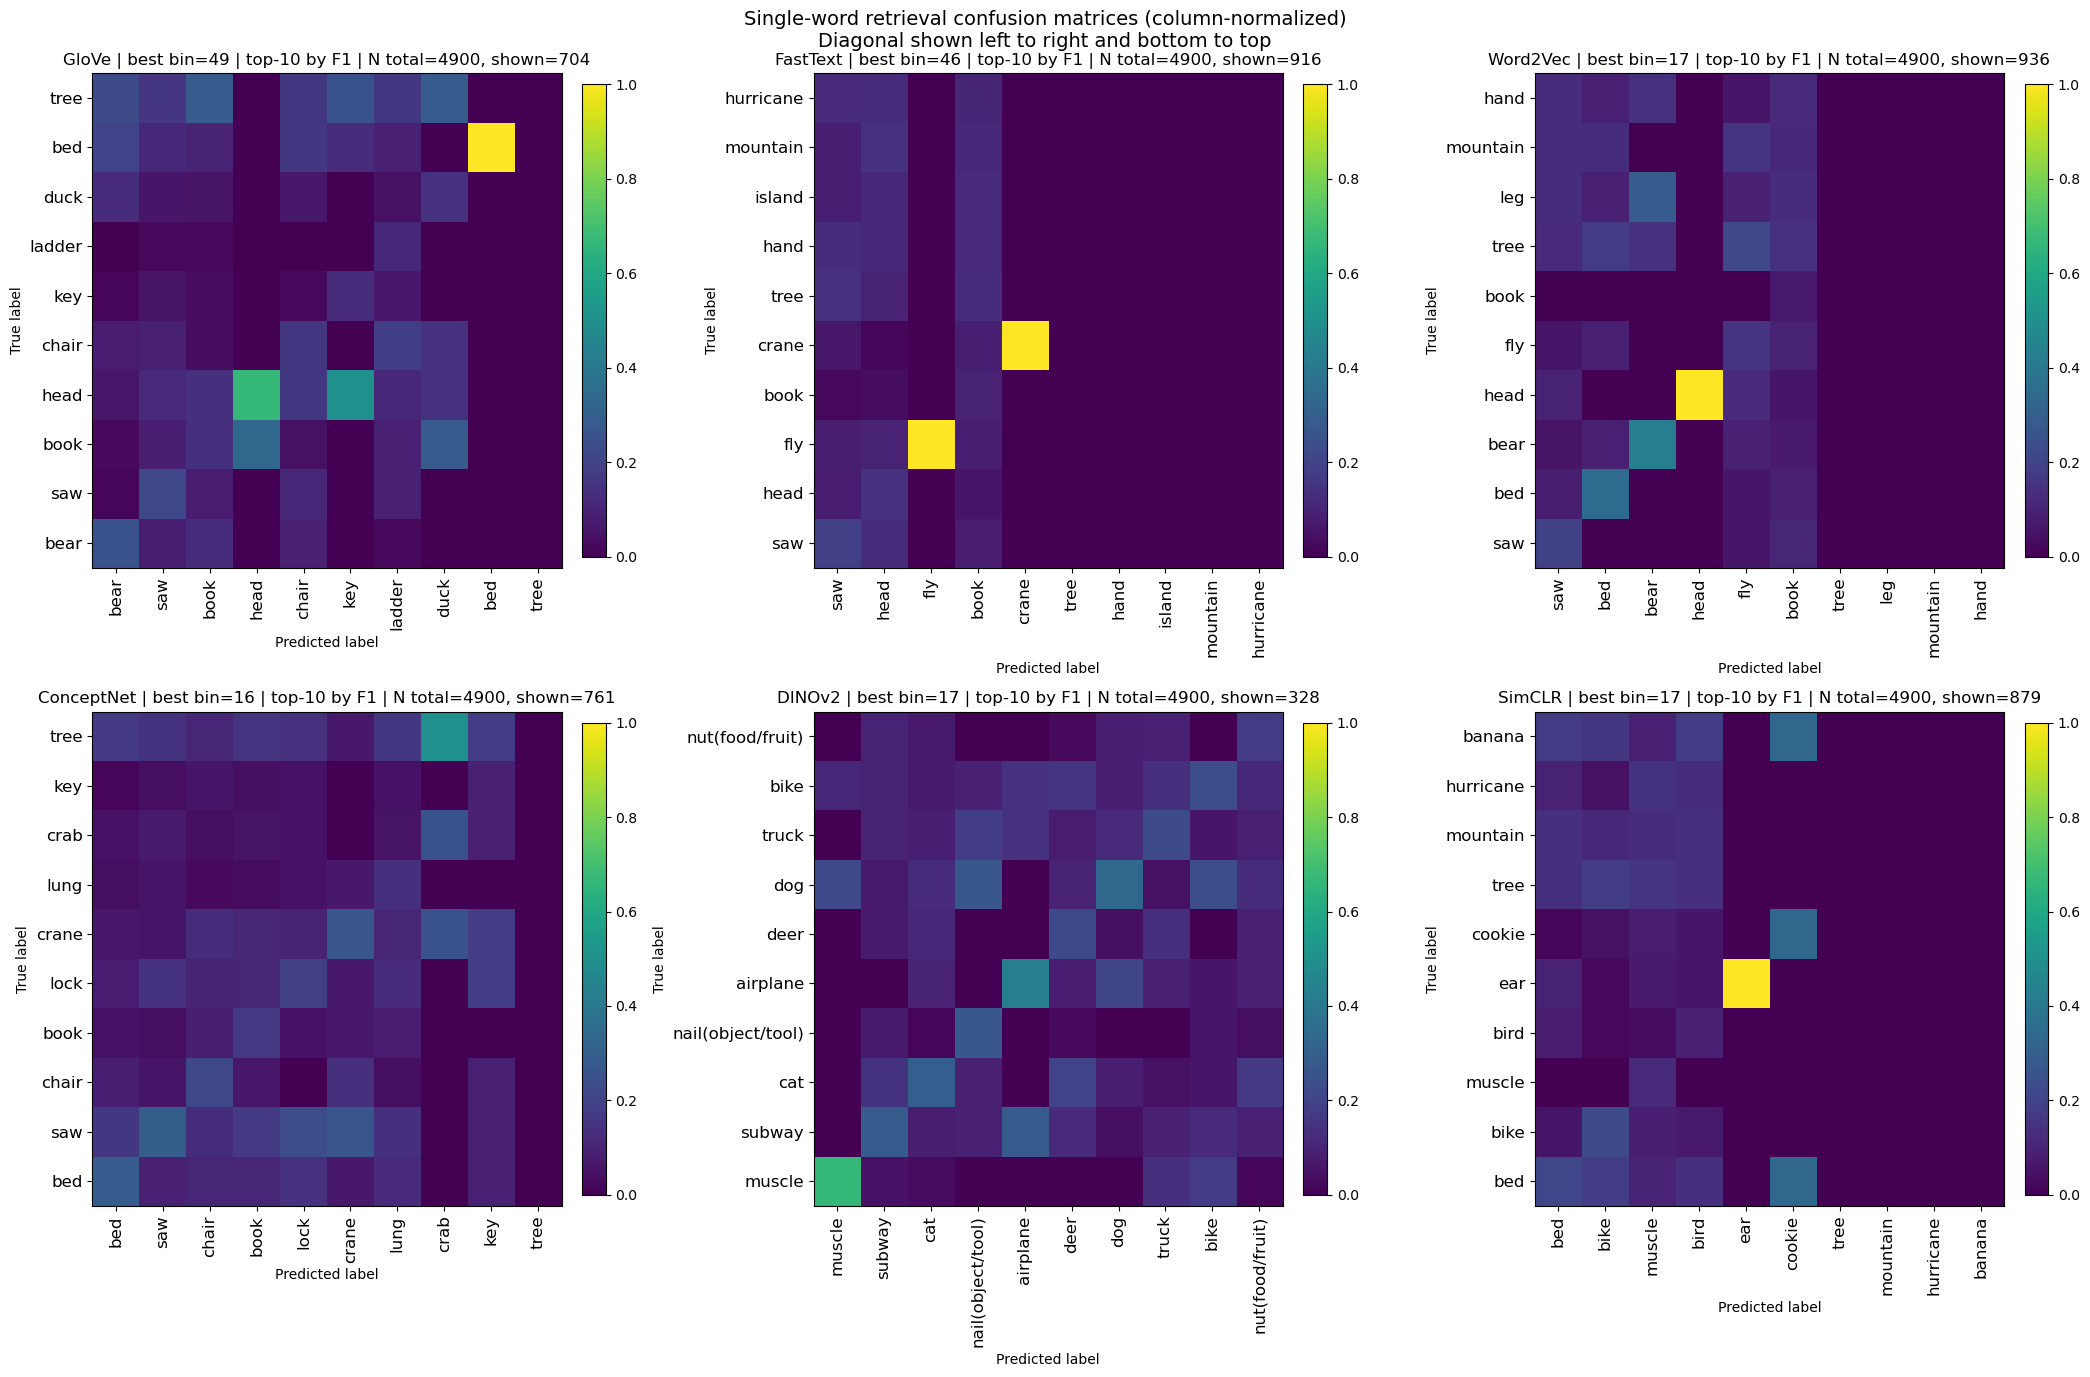

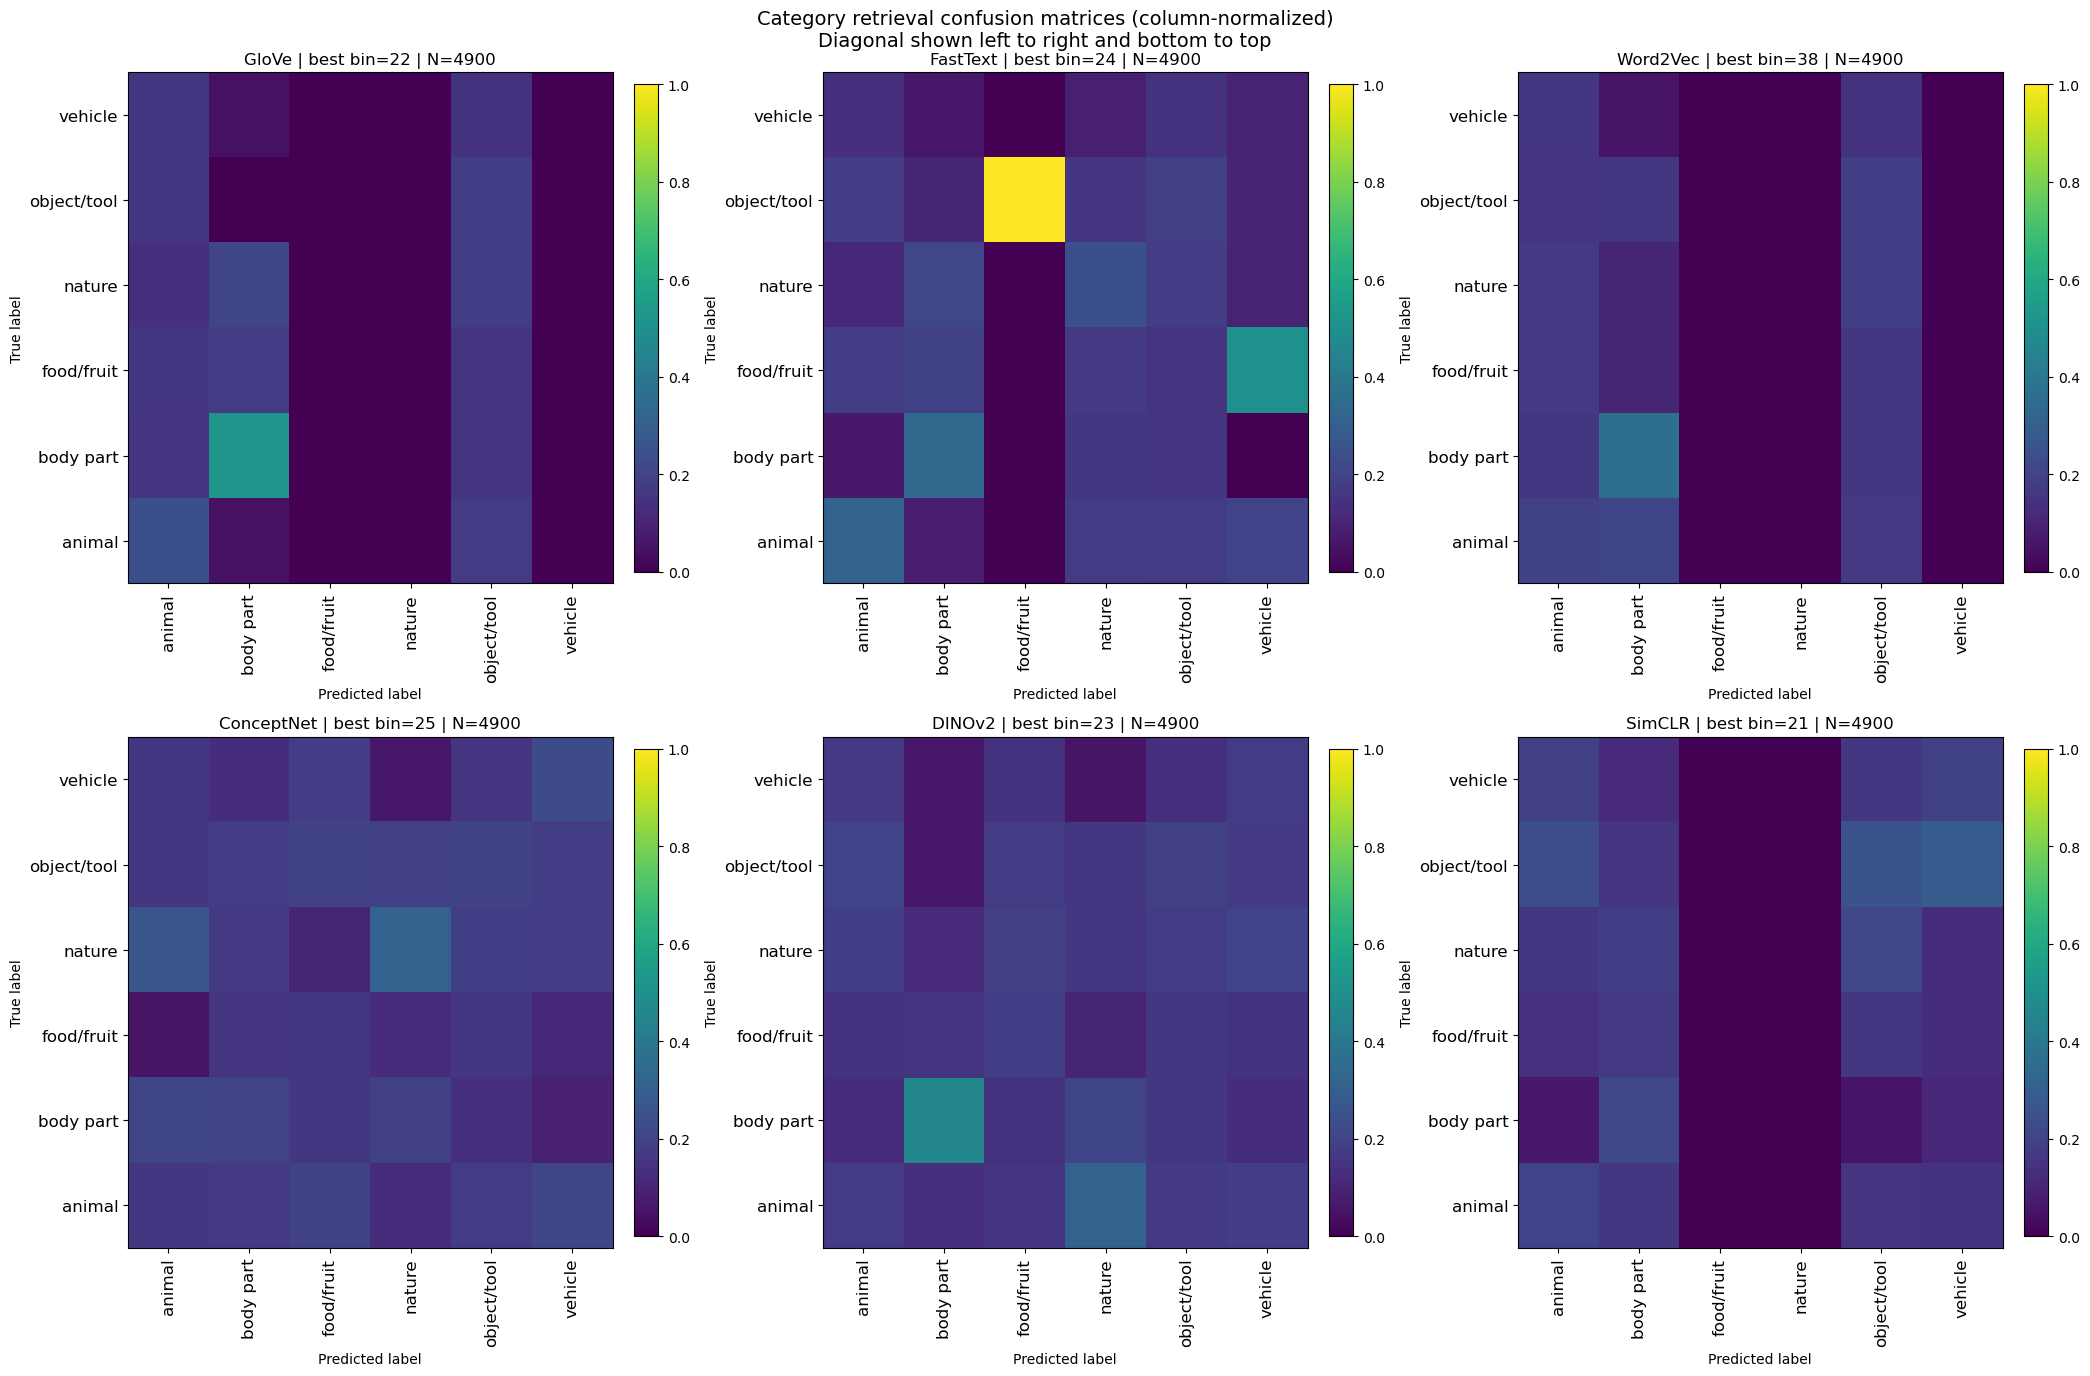

In [ ]:
model_map = {
    'GloVe': br_GloVe,
    'FastText': br_FastText,
    'Word2Vec': br_Word2Vec,
    'ConceptNet': br_ConceptNet,
    'DINOv2': br_DINOv2,
    'SimCLR': br_SimCLR,
}

cm_cmap = 'viridis'

# 1) Single-word retrieval confusion matrices (top 10 labels by per-class F1)
_plot_cm_grid(model_map, mode='word', normalize=True, cmap=cm_cmap, top_k_words_by_f1=10)

# 2) Category retrieval confusion matrices
_plot_cm_grid(model_map, mode='category', normalize=True, cmap=cm_cmap)


## 10. Per-word Sample Count vs. Decoding Accuracy


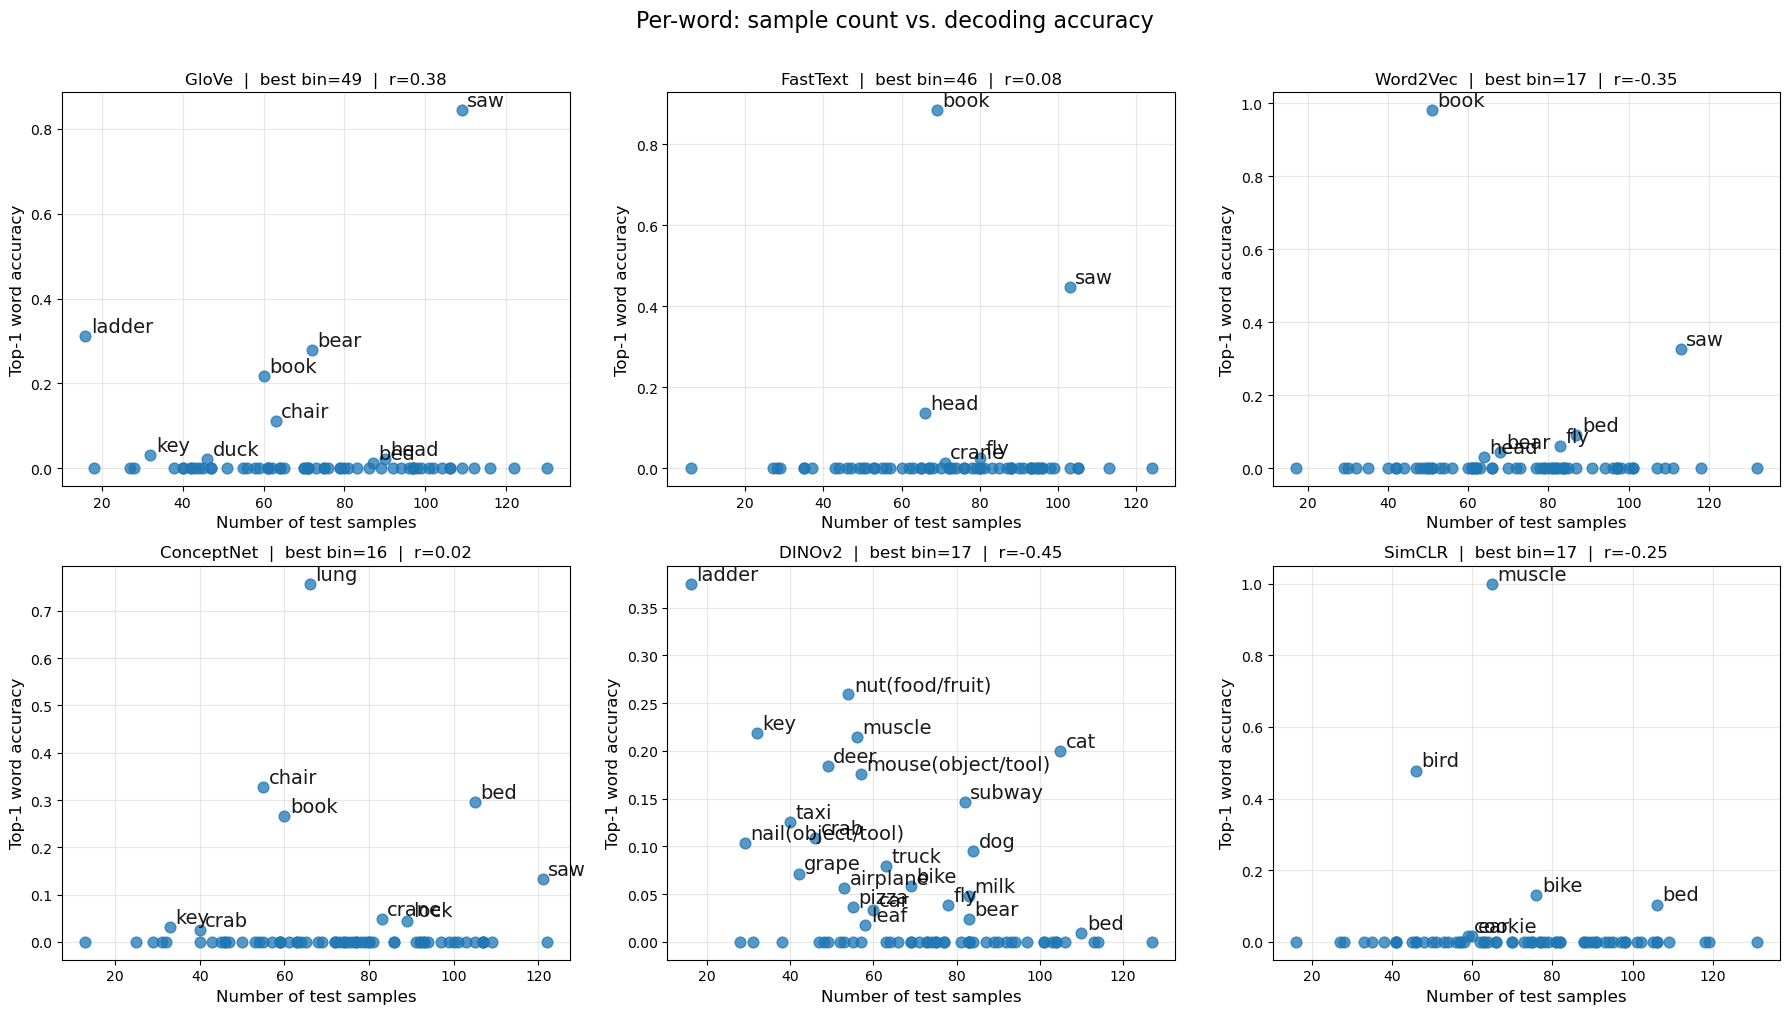

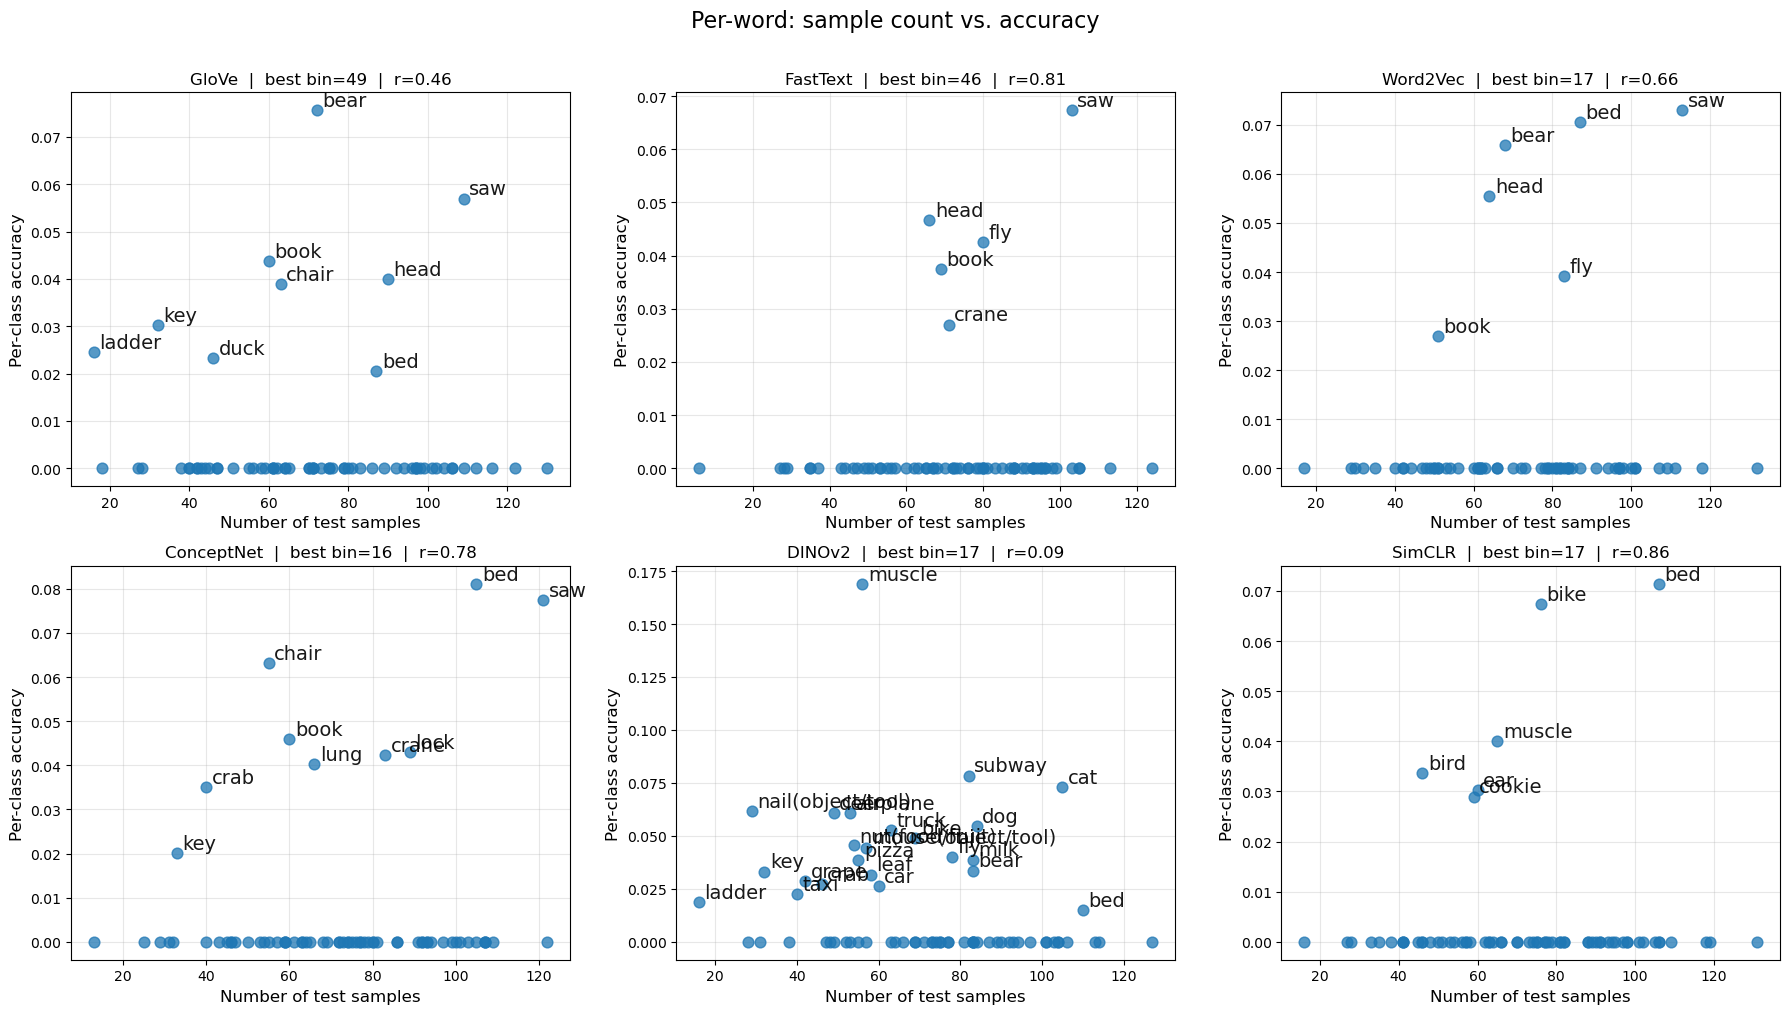

In [ ]:

def _per_word_stats(br, bin_index=None):
    """
    Returns (words, counts, accuracy) arrays aligned by word index,
    computed from saved retrieval pairs at the given (or best) time bin.

    - counts : total number of test samples for each word across all epochs
    - accuracy: fraction of those samples where top-1 predicted word == true word
    """
    if bin_index is None:
        bin_index = _best_bin_from_top1(br, mode='word')
    y_true, y_pred = _collect_pairs_at_bin(br, bin_index)

    n_words = len(br.index_to_word)
    counts = np.zeros(n_words, dtype=int)
    correct = np.zeros(n_words, dtype=int)

    for w_idx in range(n_words):
        mask = y_true == w_idx
        counts[w_idx] = mask.sum()
        correct[w_idx] = (y_pred[mask] == w_idx).sum()

    accuracy = np.where(counts > 0, correct / counts, np.nan)
    return br.index_to_word, counts, accuracy, bin_index


def _per_word_f1_stats(br, bin_index=None):
    """
    Returns (words, counts, f1) arrays aligned by word index,
    computed from the confusion matrix at the given (or best) time bin.

    - counts : row-sum of the confusion matrix (total true instances per word)
    - f1     : per-class F1 score; NaN for words with no test samples
    """
    cm, names, bin_index = _make_cm(br, bin_index=bin_index, mode='word')
    tp = np.diag(cm).astype(float)
    fp = cm.sum(axis=0).astype(float) - tp
    fn = cm.sum(axis=1).astype(float) - tp
    denom = 2.0 * tp + fp + fn
    f1 = np.divide(2.0 * tp, denom, out=np.zeros_like(tp), where=denom > 0)
    counts = cm.sum(axis=1).astype(int)
    f1 = np.where(counts > 0, f1, np.nan)
    return names, counts, f1, bin_index


def plot_count_vs_accuracy(model_map, figsize_per_panel=(6, 5)):
    """
    Scatter plot: x = number of test samples per word,
                  y = top-1 word-retrieval accuracy at the best time bin.
    Each dot is labelled with the word string.
    One panel per model.
    """
    n_models = len(model_map)
    n_cols = min(3, n_models)
    n_rows = math.ceil(n_models / n_cols)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        squeeze=False,
    )
    axes_flat = axes.ravel()

    for ax, (model_name, br) in zip(axes_flat, model_map.items()):
        words, counts, acc, best_bin = _per_word_stats(br)
        valid = ~np.isnan(acc)

        ax.scatter(counts[valid], acc[valid], s=60, alpha=0.75, zorder=3)

        # Only annotate non-zero accuracy points; use larger label text.
        for w, c, a in zip(words[valid], counts[valid], acc[valid]):
            if a <= 0:
                continue
            ax.annotate(
                w, (c, a),
                textcoords='offset points', xytext=(4, 3),
                fontsize=14, alpha=0.9,
            )

        # Pearson r annotation (exclude zero-accuracy points)
        nonzero = valid & (acc > 0)
        if nonzero.sum() >= 2:
            r = np.corrcoef(counts[nonzero].astype(float), acc[nonzero])[0, 1]
            ax.set_title(f'{model_name}  |  best bin={best_bin}  |  r={r:.2f}')
        else:
            ax.set_title(f'{model_name}  |  best bin={best_bin}')

        ax.set_xlabel('Number of test samples', fontsize=12)
        ax.set_ylabel('Top-1 word accuracy', fontsize=12)
        ax.grid(True, alpha=0.3)

    # Hide unused panels
    for ax in axes_flat[n_models:]:
        ax.set_visible(False)

    fig.suptitle('Per-word: sample count vs. decoding accuracy', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_count_vs_f1(model_map, figsize_per_panel=(6, 5)):
    """
    Scatter plot: x = number of test samples per word (row sum of CM),
                  y = per-class F1 score at the best time bin.
    Each dot is labelled with the word string.
    One panel per model.
    """
    n_models = len(model_map)
    n_cols = min(3, n_models)
    n_rows = math.ceil(n_models / n_cols)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        squeeze=False,
    )
    axes_flat = axes.ravel()

    for ax, (model_name, br) in zip(axes_flat, model_map.items()):
        words, counts, f1, best_bin = _per_word_f1_stats(br)
        valid = ~np.isnan(f1)

        ax.scatter(counts[valid], f1[valid], s=60, alpha=0.75, zorder=3)

        # Only annotate non-zero F1 points.
        for w, c, v in zip(words[valid], counts[valid], f1[valid]):
            if v <= 0:
                continue
            ax.annotate(
                w, (c, v),
                textcoords='offset points', xytext=(4, 3),
                fontsize=14, alpha=0.9,
            )
        # Pearson r annotation (exclude zero-F1 points)
        nonzero = valid & (f1 > 0)
        if nonzero.sum() >= 2:
            r = np.corrcoef(counts[nonzero].astype(float), f1[nonzero])[0, 1]
            ax.set_title(f'{model_name}  |  best bin={best_bin}  |  r={r:.2f}')
        else:
            ax.set_title(f'{model_name}  |  best bin={best_bin}')

        ax.set_xlabel('Number of test samples', fontsize=12)
        ax.set_ylabel('Per-class accuracy', fontsize=12)
        ax.grid(True, alpha=0.3)

    # Hide unused panels
    for ax in axes_flat[n_models:]:
        ax.set_visible(False)

    fig.suptitle('Per-word: sample count vs. accuracy', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()


plot_count_vs_accuracy(model_map)
plot_count_vs_f1(model_map)

